Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1.Imagem carregada


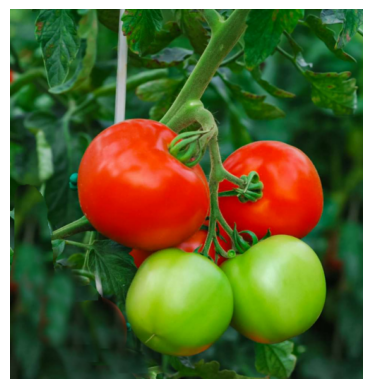

2.Imagem passada para a escala de cinza


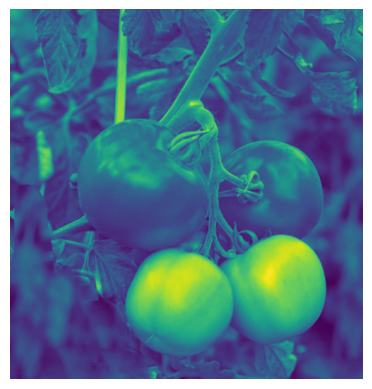

3.Imagem passada pelo detectar bordas de Canny


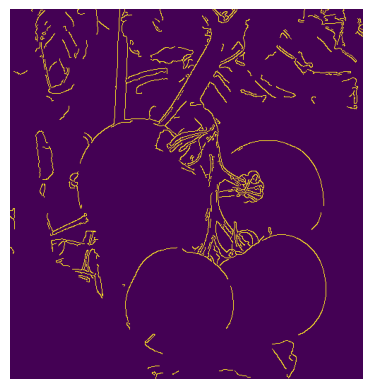

4. Detectar círculos com a Transformada de Hough
Detectados 4 círculos distintos
Detecções de Círculo (Centro X, Centro Y, Raio):
  (367, 261, 75)
  (240, 417, 76)
  (368, 394, 80)
  (190, 248, 96)
5. Desenhar círculos detectados na imagem e exibir


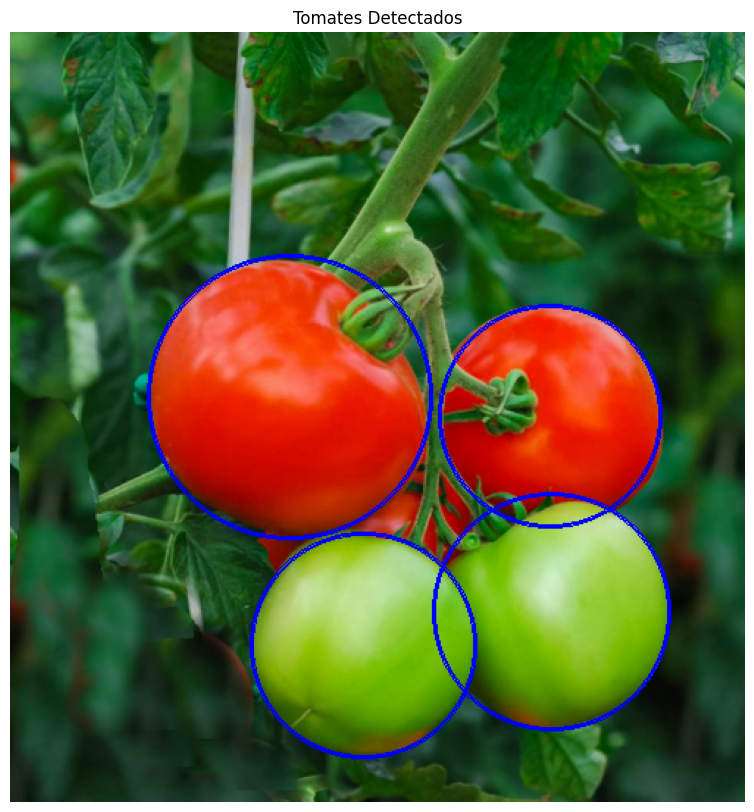

In [8]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import skimage.io as io
import matplotlib.pyplot as plt
from skimage import transform, feature, color, draw
import cv2

#1. Carrega a imagem
img = io.imread('/content/drive/MyDrive/Pesquisa/Visão Computacional/imagens/Quest4/tomates.png')

print("1.Imagem carregada")
plt.imshow(img)
plt.axis('off')
plt.show()

# 2. Passar a imagem para a escala de cinza
img_gray = color.rgb2gray(img)

print("2.Imagem passada para a escala de cinza")
plt.imshow(img_gray)
plt.axis('off')
plt.show()

# 3. Detectar bordas com Canny
threshold1 = 100
threshold2 = 200

# Convertendo img_gray para 8-bit unsigned integer (CV_8U) para usar cv2.Canny
img_gray_uint8 = (img_gray * 255).astype(np.uint8)
edges = cv2.Canny(img_gray_uint8, threshold1, threshold2)

print("3.Imagem passada pelo detectar bordas de Canny")
plt.imshow(edges)
plt.axis('off')
plt.show()

# 4. Detectar círculos com a Transformada de Hough
min_radius = 75
max_radius = 100
radii = np.arange(min_radius, max_radius)

h_space = transform.hough_circle(edges, radii)

# Detectar o número alvo de círculos diretamente com hough_circle_peaks
accumulators_sk, centers_x_sk, centers_y_sk, radii_detected_sk = transform.hough_circle_peaks(h_space,
                                                                                                radii,
                                                                                                num_peaks=2,
                                                                                                min_xdistance=100,
                                                                                                min_ydistance=120)
# imprime os circulos detectados
print(f"4. Detectar círculos com a Transformada de Hough")
print(f"Detectados {len(centers_x_sk)} círculos distintos")
print("Detecções de Círculo (Centro X, Centro Y, Raio):")
for x, y, r in zip(centers_x_sk, centers_y_sk, radii_detected_sk):
    print(f"  ({x}, {y}, {r})")

# 5. Desenhar círculos detectados na imagem e exibir
# Criar uma cópia da imagem para desenhar
image_with_circles_sk = img.copy()

# Definir a espessura da borda desejada
border_thickness = 3 # Exemplo: 3 pixels

# Desenhar os círculos detectados
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(10, 10))
ax.imshow(image_with_circles_sk)

for center_y, center_x, radius in zip(centers_y_sk, centers_x_sk, radii_detected_sk):
    # Desenhar o perímetro do círculo com espessura
    for t in range(int(-border_thickness/2), int(border_thickness/2) + 1):
        circy, circx = draw.circle_perimeter(center_y, center_x, radius + t, shape=image_with_circles_sk.shape)
        image_with_circles_sk[circy, circx] = (0, 0, 255)

print("5. Desenhar círculos detectados na imagem e exibir")
ax.set_title('Tomates Detectados')
plt.imshow(image_with_circles_sk)
plt.axis('off')
plt.show()